# 04 — Baseline ML Models
**Place in:** `ECG_Fatigue/notebooks/`

Trains Logistic Regression, Random Forest, and XGBoost on `features.csv`.
At the end it prints the 6 numbers you paste into `06_pretrain_cnn.ipynb` Cell 13.

In [3]:
# ── Cell 1: Imports & load features ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (roc_auc_score, confusion_matrix,
                                      classification_report, roc_curve)
import xgboost as xgb
import shap

PATH_FEATURES = '../Data/features.csv'
PATH_RESULTS  = '../results'
PATH_MODELS   = '../src/models'
os.makedirs(PATH_RESULTS, exist_ok=True)
os.makedirs(PATH_MODELS,  exist_ok=True)

df = pd.read_csv(PATH_FEATURES)
print(f'Feature matrix shape : {df.shape}')
print(f'True alarms  (1)     : {(df["label"]==1).sum()}')
print(f'False alarms (0)     : {(df["label"]==0).sum()}')
df.head(3)

Feature matrix shape : (748, 32)
True alarms  (1)     : 294
False alarms (0)     : 454


,record_id,has_pleth,has_abp,n_channels,ecg_mean,ecg_std,ecg_kurtosis,ecg_skew,ecg_energy,hr_mean,...,win_rr_std,win_short_rr_ratio,win_long_rr_ratio,pleth_mean,pleth_std,abp_mean,abp_std,abp_pp,label,alarm_type
0,v845l,0,1,4,0.000296,0.227354,3.094613,-0.959531,0.051690,96.567455,...,157.894338,0.0,0.0,0.0,0.0,72.637963,11.479909,76.397881,0,Ventricular_Tachycardia
1,b578s,0,1,4,-0.000004,0.076535,12.487496,2.746416,0.005858,71.330132,...,295.058180,0.0,0.0,0.0,0.0,84.788301,27.452401,115.501166,1,Bradycardia
2,f493l,0,1,4,0.000642,0.528925,-0.828182,-0.135860,0.279762,98.196495,...,88.738251,0.0,0.0,0.0,0.0,69.477026,18.769529,85.937500,0,Ventricular_Flutter_Fib


In [4]:
# ── Cell 2: Prepare X and y ───────────────────────────────────────────────────
drop_cols    = ['record_id', 'label', 'alarm_type']
X            = df.drop(columns=[c for c in drop_cols if c in df.columns])
y            = df['label'].values
feature_names = list(X.columns)

# Fill any leftover NaN with column median
X = X.fillna(X.median())

print(f'Features  : {len(feature_names)}')
print(f'Samples   : {len(X)}')
print(f'NaN left  : {X.isna().sum().sum()}')   # must be 0
print(f'\nFeature list:')
print(feature_names)

Features  : 29
Samples   : 748
NaN left  : 0

Feature list:
['has_pleth', 'has_abp', 'n_channels', 'ecg_mean', 'ecg_std', 'ecg_kurtosis', 'ecg_skew', 'ecg_energy', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'rr_mean', 'rr_std', 'rmssd', 'n_peaks', 'short_rr_ratio', 'long_rr_ratio', 'win_ecg_std', 'win_ecg_energy', 'win_hr_mean', 'win_rr_std', 'win_short_rr_ratio', 'win_long_rr_ratio', 'pleth_mean', 'pleth_std', 'abp_mean', 'abp_std', 'abp_pp']


In [5]:
# ── Cell 3: 5-fold CV evaluation function ─────────────────────────────────────
def evaluate_cv(name, model, X, y, n_splits=5):
    """
    Runs stratified 5-fold CV and returns mean/std AUC.
    Also prints sensitivity, specificity, and confusion matrix
    from the best fold so you can see clinical metrics.
    """
    kfold     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_aucs = []
    all_proba, all_true = [], []

    for tr_i, va_i in kfold.split(X, y):
        X_tr, X_va = X.iloc[tr_i], X.iloc[va_i]
        y_tr, y_va = y[tr_i],      y[va_i]

        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]

        fold_aucs.append(roc_auc_score(y_va, proba))
        all_proba.extend(proba)
        all_true.extend(y_va)

    mean_auc = float(np.mean(fold_aucs))
    std_auc  = float(np.std(fold_aucs))

    # Pooled predictions for confusion matrix
    all_proba = np.array(all_proba)
    all_true  = np.array(all_true)
    preds     = (all_proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_true, preds).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    print(f'\n{"="*48}')
    print(f'  {name}')
    print(f'{"="*48}')
    print(f'  AUC (5-fold CV)    : {mean_auc:.3f} ± {std_auc:.3f}')
    print(f'  Sensitivity        : {sensitivity:.3f}   ← true alarms caught')
    print(f'  Specificity        : {specificity:.3f}   ← false alarms suppressed')
    print(f'  Confusion matrix   :')
    print(f'    True False caught     : {tp}/{tp+fn}')
    print(f'    False alarms caught   : {tn}/{tn+fp}')

    return mean_auc, std_auc, model

print('✅ Evaluation function ready')

✅ Evaluation function ready


In [6]:
# ── Cell 4: Logistic Regression ───────────────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced',
                   max_iter=1000,
                   random_state=42))
])

mean_auc_lr, std_auc_lr, lr_model = evaluate_cv(
    'Logistic Regression', lr_pipe, X, y)


  Logistic Regression
  AUC (5-fold CV)    : 0.766 ± 0.011
  Sensitivity        : 0.765   ← true alarms caught
  Specificity        : 0.654   ← false alarms suppressed
  Confusion matrix   :
    True False caught     : 225/294
    False alarms caught   : 297/454


In [7]:
# ── Cell 5: Random Forest ─────────────────────────────────────────────────────
rf_model_raw = RandomForestClassifier(
    n_estimators = 300,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

mean_auc_rf, std_auc_rf, rf_model = evaluate_cv(
    'Random Forest', rf_model_raw, X, y)


  Random Forest
  AUC (5-fold CV)    : 0.835 ± 0.036
  Sensitivity        : 0.711   ← true alarms caught
  Specificity        : 0.797   ← false alarms suppressed
  Confusion matrix   :
    True False caught     : 209/294
    False alarms caught   : 362/454


In [8]:
# ── Cell 6: XGBoost ───────────────────────────────────────────────────────────
scale_pos = float((y == 0).sum()) / float((y == 1).sum())
print(f'scale_pos_weight = {scale_pos:.2f}  (handles class imbalance)')

xgb_model_raw = xgb.XGBClassifier(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    eval_metric      = 'auc',
    random_state     = 42,
    n_jobs           = -1
)

mean_auc_xgb, std_auc_xgb, xgb_model = evaluate_cv(
    'XGBoost', xgb_model_raw, X, y)

scale_pos_weight = 1.54  (handles class imbalance)

  XGBoost
  AUC (5-fold CV)    : 0.825 ± 0.029
  Sensitivity        : 0.714   ← true alarms caught
  Specificity        : 0.817   ← false alarms suppressed
  Confusion matrix   :
    True False caught     : 210/294
    False alarms caught   : 371/454



  ML MODEL COMPARISON
              Model      AUC      Std
Logistic Regression 0.766306 0.010662
      Random Forest 0.834879 0.035619
            XGBoost 0.824501 0.029291


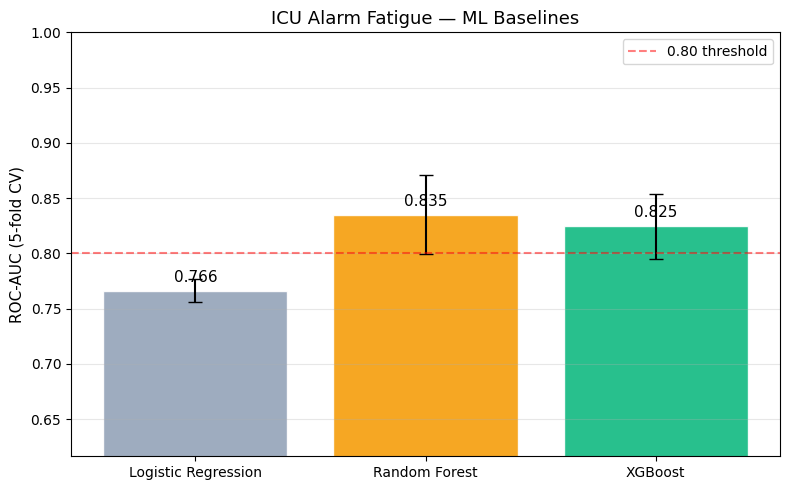

In [9]:
# ── Cell 7: Comparison table + chart ─────────────────────────────────────────
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'AUC': mean_auc_lr,  'Std': std_auc_lr},
    {'Model': 'Random Forest',       'AUC': mean_auc_rf,  'Std': std_auc_rf},
    {'Model': 'XGBoost',             'AUC': mean_auc_xgb, 'Std': std_auc_xgb},
])

print('\n' + '='*48)
print('  ML MODEL COMPARISON')
print('='*48)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#94A3B8', '#F59E0B', '#10B981']
bars   = ax.bar(results['Model'], results['AUC'],
                yerr=results['Std'], color=colors,
                capsize=5, edgecolor='white', alpha=0.9)
ax.set_ylim(max(0.0, results['AUC'].min() - 0.15), 1.0)
ax.set_ylabel('ROC-AUC (5-fold CV)', fontsize=11)
ax.set_title('ICU Alarm Fatigue — ML Baselines', fontsize=13)
ax.axhline(0.80, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results['AUC']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/04_ml_comparison.png', dpi=150)
plt.show()

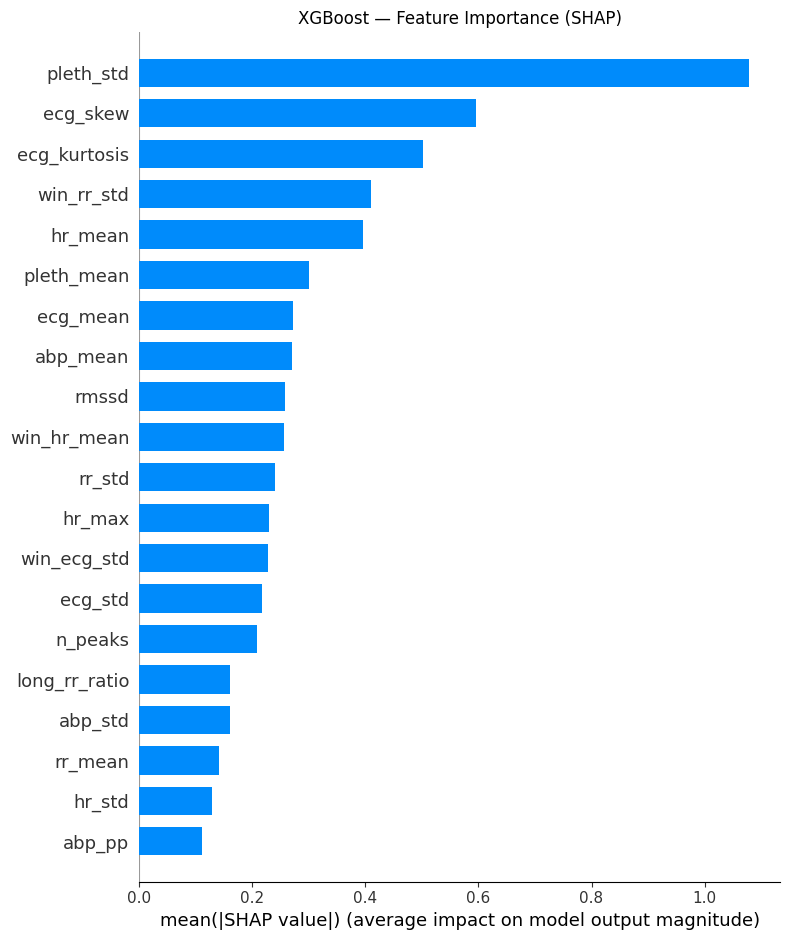

✅ SHAP plot saved → ../results/05_shap_importance.png


In [10]:
# ── Cell 8: SHAP feature importance (XGBoost) ────────────────────────────────
# Retrain XGBoost on full data for SHAP
xgb_model.fit(X, y)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('XGBoost — Feature Importance (SHAP)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/05_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ SHAP plot saved → {PATH_RESULTS}/05_shap_importance.png')

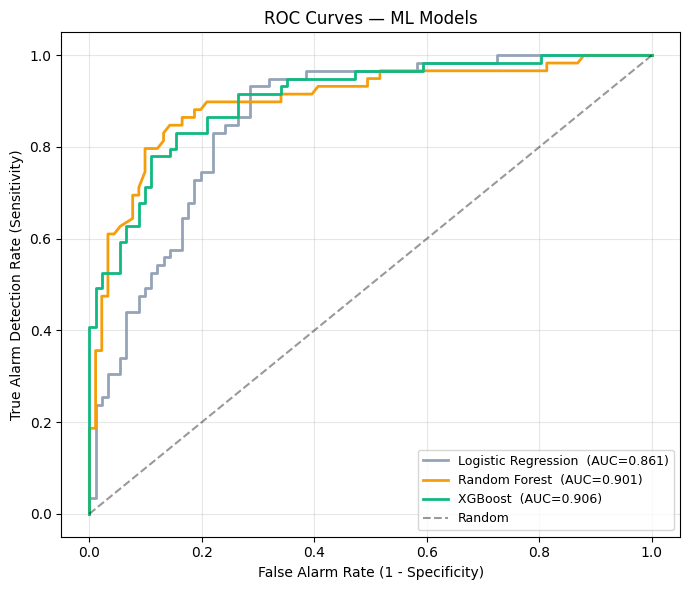

In [11]:
# ── Cell 9: ROC curves for all 3 models ──────────────────────────────────────
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

fig, ax = plt.subplots(figsize=(7, 6))

for name, mdl, color in [
    ('Logistic Regression', lr_pipe,      '#94A3B8'),
    ('Random Forest',       rf_model,     '#F59E0B'),
    ('XGBoost',             xgb_model,    '#10B981'),
]:
    mdl.fit(X_tr, y_tr)
    proba       = mdl.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc         = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})',
            color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Alarm Rate (1 - Specificity)')
ax.set_ylabel('True Alarm Detection Rate (Sensitivity)')
ax.set_title('ROC Curves — ML Models')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PATH_RESULTS}/06_roc_curves.png', dpi=150)
plt.show()

In [12]:
# ── Cell 10: Save models + print copy-paste block ────────────────────────────
xgb_model.fit(X, y)   # final fit on full data
rf_model.fit(X, y)

with open(f'{PATH_MODELS}/xgboost_model.pkl', 'wb') as f:
    pickle.dump({'model': xgb_model, 'features': feature_names}, f)
with open(f'{PATH_MODELS}/rf_model.pkl', 'wb') as f:
    pickle.dump({'model': rf_model,  'features': feature_names}, f)

print('✅ Models saved to src/models/')
print()
print('=' * 55)
print('  COPY THESE NUMBERS INTO 06_pretrain_cnn.ipynb')
print('  (the cell just before Cell 13)')
print('=' * 55)
print(f'mean_auc_lr  = {mean_auc_lr:.3f}')
print(f'std_auc_lr   = {std_auc_lr:.3f}')
print()
print(f'mean_auc_rf  = {mean_auc_rf:.3f}')
print(f'std_auc_rf   = {std_auc_rf:.3f}')
print()
print(f'mean_auc_xgb = {mean_auc_xgb:.3f}')
print(f'std_auc_xgb  = {std_auc_xgb:.3f}')
print('=' * 55)

✅ Models saved to src/models/

  COPY THESE NUMBERS INTO 06_pretrain_cnn.ipynb
  (the cell just before Cell 13)
mean_auc_lr  = 0.766
std_auc_lr   = 0.011

mean_auc_rf  = 0.835
std_auc_rf   = 0.036

mean_auc_xgb = 0.825
std_auc_xgb  = 0.029
